# 01. EDA

Notebook para documentar el análisis exploratorio del dataset maestro.


In [ ]:
## Objetivo del análisis exploratorio
El presente cuaderno tiene como finalidad caracterizar los conjuntos de datos generados tras la fase de preprocesamiento, con el propósito de verificar su consistencia, distribución de clases y adecuación para la fase de modelado. En particular, se analizan los archivos `train.csv`, `val.csv`, `test.csv` y `external_validation_detoxis.csv`, prestando atención al número de registros, el balance entre clases, la longitud de los textos y la existencia de posibles problemas de calidad, tales como valores nulos o duplicados.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = BASE_DIR / "data" / "processed"
OUTPUTS_TABLES = BASE_DIR / "outputs" / "tables"
OUTPUTS_FIGURES = BASE_DIR / "outputs" / "figures"
OUTPUTS_METRICS = BASE_DIR / "outputs" / "metrics"

OUTPUTS_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUTS_METRICS.mkdir(parents=True, exist_ok=True)



In [2]:
train_df = pd.read_csv(DATA_PROCESSED / "train.csv")
val_df = pd.read_csv(DATA_PROCESSED / "val.csv")
test_df = pd.read_csv(DATA_PROCESSED / "test.csv")
ext_df = pd.read_csv(DATA_PROCESSED / "external_validation_detoxis.csv")
summary_df = pd.read_csv(DATA_PROCESSED / "dataset_summary.csv")
summary_df


,file,rows,label_0,label_1
0,master_train_full.csv,10260,6130,4130
1,train.csv,7182,4291,2891
2,val.csv,1539,919,620
3,test.csv,1539,920,619
4,external_validation_detoxis.csv,3434,2296,1138


In [3]:
dist = pd.DataFrame([
    {"split":"train","rows":len(train_df),"label_0":int((train_df["label"]==0).sum()),"label_1":int((train_df["label"]==1).sum())},
    {"split":"val","rows":len(val_df),"label_0":int((val_df["label"]==0).sum()),"label_1":int((val_df["label"]==1).sum())},
    {"split":"test","rows":len(test_df),"label_0":int((test_df["label"]==0).sum()),"label_1":int((test_df["label"]==1).sum())},
    {"split":"external_validation_detoxis","rows":len(ext_df),"label_0":int((ext_df["label"]==0).sum()),"label_1":int((ext_df["label"]==1).sum())},
])
dist.to_csv(OUTPUTS_TABLES / "eda_label_distribution.csv", index=False, encoding="utf-8-sig")
dist


,split,rows,label_0,label_1
0,train,7182,4291,2891
1,val,1539,919,620
2,test,1539,920,619
3,external_validation_detoxis,3434,2296,1138


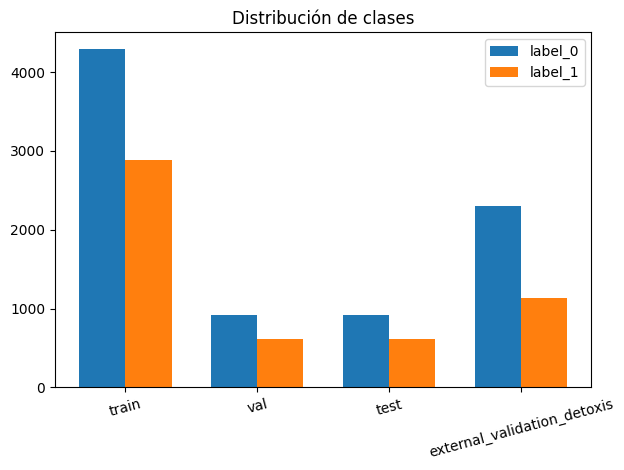

In [4]:
fig, ax = plt.subplots()
x = np.arange(len(dist))
w = 0.35
ax.bar(x - w/2, dist["label_0"], w, label="label_0")
ax.bar(x + w/2, dist["label_1"], w, label="label_1")
ax.set_xticks(x)
ax.set_xticklabels(dist["split"], rotation=15)
ax.set_title("Distribución de clases")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUTS_FIGURES / "eda_distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()


In [5]:
for name, df in {"train":train_df, "val":val_df, "test":test_df, "external":ext_df}.items():
    print("="*60)
    print(name)
    print(df[["text_clean","label"]].head(3))


train
                                          text_clean  label
0  a este tambien lo habia que echar porque era u...      1
1  pero no temáis, puesto que el hdp se encargó d...      0
2  desde nusco llegarán los congeladores para la ...      0
val
                                          text_clean  label
0  no haces el amor con tu mujer, no la atiendes ...      1
1  te imaginas la rabia que debe sentir un japone...      0
2  me encanta este poema de nicolás guillén, dond...      0
test
                                          text_clean  label
0  te lo mereces wey, eres un chingón, te la rifa...      0
1  en cualquier caso, al otro lado del atlántico ...      0
2  el aguante de la gente que sigue a macri se me...      0
external
                                          text_clean  label
0                           pensó: zumo para restar.      1
1   como les gusta el afeitado en seco a esta gente.      1
2  asi me gusta, que se maten entre ellos y en al...      1


In [ ]:
## Observaciones del EDA

A partir del archivo `dataset_summary.csv`, se observa que el conjunto maestro de entrenamiento quedó compuesto por 10,260 registros, resultado de la integración del subconjunto en español de `multilingual_toxicity_dataset` y del corpus `CLANDESTINO`. La distribución de clases en este conjunto no es perfectamente balanceada, ya que se registran 6,130 ejemplos de la clase 0 y 4,130 ejemplos de la clase 1. Esto indica un desbalance moderado que debe tenerse en cuenta durante el modelado.

La partición de los datos se realizó en tres subconjuntos internos: entrenamiento, validación y prueba. El archivo `train.csv` contiene 7,182 registros, `val.csv` contiene 1,539 y `test.csv` otros 1,539. La validación externa se llevó a cabo con `external_validation_detoxis.csv`, compuesto por 3,434 registros, con una distribución de 2,296 ejemplos para la clase 0 y 1,138 para la clase 1.

Desde un punto de vista metodológico, esta estructura es adecuada para la fase de modelado, ya que permite evaluar el comportamiento del modelo tanto en datos internos como en un corpus externo, lo que aporta una visión más realista de su capacidad de generalización. Asimismo, la existencia de un conjunto de validación externa introduce un escenario de cambio de dominio, especialmente útil para valorar la robustez de los modelos.

## Conclusiones del EDA

El análisis exploratorio confirma que el pipeline de preprocesamiento produjo conjuntos de datos consistentes y utilizables para la fase de modelado. La integración de `CLANDESTINO` permitió ampliar el volumen de datos de entrenamiento, aunque introdujo un desbalance moderado entre clases. No obstante, este nivel de desbalance no impide el entrenamiento de modelos supervisados y puede ser tratado mediante estrategias de modelado apropiadas.

En conjunto, los datos presentan una estructura adecuada para continuar con la construcción de modelos de clasificación binaria. La disponibilidad de particiones internas y de un conjunto de validación externa constituye un elemento especialmente valioso, ya que permite medir tanto el ajuste interno como la capacidad de generalización fuera del dominio principal de entrenamiento.
